# Phonons acting on the electrons: the Fan–Migdal self-energy

Notebook 13 and notebook 24 ask how phonons **scatter** the carriers — the
Eliashberg function $\alpha^2F$, the transport kernel, the resistivity. This
notebook asks the complementary question: what do phonons do to the **bands**
themselves?

Both contract the same object, the validated electron–phonon vertex
$g(\mathbf R_e,\mathbf R_q)$ that notebook 13 built for aluminium. Transport
puts it on the Fermi surface with a velocity weight. Here it becomes a
frequency-dependent self-energy that reshapes the dispersion:

$$\Sigma_{n\mathbf k}(\omega) = \frac{1}{N_q}\sum_{\mathbf q\nu m}
\bigl|g^{\nu}_{mn}(\mathbf k,\mathbf q)\bigr|^2
\left[\frac{n_{\mathbf q\nu}+f_{m\mathbf k+\mathbf q}}
{\omega-\varepsilon_{m\mathbf k+\mathbf q}+\omega_{\mathbf q\nu}+i\eta}
+\frac{n_{\mathbf q\nu}+1-f_{m\mathbf k+\mathbf q}}
{\omega-\varepsilon_{m\mathbf k+\mathbf q}-\omega_{\mathbf q\nu}+i\eta}\right]$$

(Giustino, *Rev. Mod. Phys.* **89**, 015003 (2017), Eq. 128.) ${\rm Im}\,\Sigma$
is the phonon-limited linewidth; ${\rm Re}\,\Sigma$ carries the mass
enhancement and the ARPES kink.

**Why aluminium.** Its transport is validated against experiment with no
adjustable parameter ($\rho(300\,$K$) = 2.72$ vs a measured 2.74
$\mu\Omega\,$cm, notebook 24) and its $\lambda = 0.478 \pm 0.009$ is
converged (notebook 13). So a disagreement here is the self-energy's fault and
not the input's — which is the only situation in which a new module can
actually be tested.

**What is deliberately left out.** Only the Fan–Migdal term. The Debye–Waller
contribution is *static*, so it contributes nothing to $Z$, nothing to the
kink and nothing to ${\rm Im}\,\Sigma$; it shifts bands rigidly, which matters
for absolute positions and Allen–Heine–Cardona gap renormalisation — neither
of which this notebook claims. Getting it right needs the two-phonon matrix
element that DFPT does not supply, and the rigid-ion reconstruction from
first-order couplings is a further approximation, so it is omitted rather than
guessed at. No vertex corrections either: for phonons that is Migdal's theorem
($\mathcal{O}(\omega_D/E_F)$), not an admission — and that protection does
**not** extend to magnons.

In [1]:
import sys, pathlib, warnings, time
import numpy as np
import matplotlib.pyplot as plt

HERE = pathlib.Path.cwd()
REPO = HERE
while not (REPO / 'waw').exists() and REPO != REPO.parent:
    REPO = REPO.parent
sys.path.insert(0, str(REPO))
warnings.simplefilter('ignore')

import torch
from ase import Atoms
from ase.build import bulk

import waw
waw.set_num_threads(32)
from waw.core.hamiltonian import HamiltonianR
from waw.core.distributions import gaussian_smearing
from waw.analysis import elph
from waw.analysis.elph_selfenergy import (fan_migdal_self_energy,
                                          mass_enhancement,
                                          fermi_surface_average_lambda)
from waw.analysis.spectral import bloch_spectral_function
from waw.analysis.phonon import apply_acoustic_sum_rule, interpolate_phonons
from waw.interfaces.quantum_espresso.phonon_io import read_force_constants
from waw.interfaces.ase.structure import (monkhorst_pack, irreducible_qpoints,
                                          real_lattice, band_path)
from waw.units import CM1_TO_HARTREE, HARTREE_TO_EV, EV_TO_HARTREE

RUNS = REPO / 'workflows' / 'notebooks' / 'runs'
CAT = ['#14487f', '#c1666b', '#4a7c59', '#8a6bbe']
BLUE_RAMP = ['#a8c8ec', '#7aa8dd', '#4f8bd0', '#14487f']
print('waw threads =', waw.get_num_threads())

waw threads = 32


## 1. The aluminium model, reused

Everything comes from notebook 13's cached run: the 4-MLWF $sp$ Hamiltonian,
the vertex $g(\mathbf R_e,\mathbf R_q)$ and the force constants. Nothing is
recomputed, so the vertex here is *identical* to the one that produced
$\lambda = 0.478$ — which is what makes the comparison in section 2 a test
rather than a coincidence.

The Fermi level is the **model's own**, solved from the 3-electron count of
the $sp$ manifold, not the SCF value (see notebook 24 §4 for why that
distinction is not cosmetic).

In [2]:
AL = RUNS / 'al_elph_alpha2f'
A_ANG = 4.0495
cell = A_ANG * np.array([[-0.5, 0.0, 0.5], [0.0, 0.5, 0.5], [-0.5, 0.5, 0.0]])
atoms = Atoms('Al', scaled_positions=[[0.0, 0.0, 0.0]], cell=cell, pbc=True)

zw = np.load(AL / 'al_wannier_result.npz')
hr = HamiltonianR(H_R=torch.from_numpy(zw['H_R']),
                  R_vectors=zw['R_vectors'].astype(np.int64),
                  degen=zw['degen'].astype(np.int64), nw=int(zw['nw']),
                  real_lattice=real_lattice(atoms))
zg = np.load(AL / 'al_gR.npz')
gR = (zg['g_R'], zg['R_e'], zg['degen_e'], zg['R_q'], zg['degen_q'])

fc = apply_acoustic_sum_rule(read_force_constants(AL / 'al.fc'))
q_irr, q_w = irreducible_qpoints(atoms, (6, 6, 6))
ph = interpolate_phonons(fc, real_lattice(atoms), atoms.get_scaled_positions(),
                         q_irr)
om, ev = CM1_TO_HARTREE * ph.freq_cm1, ph.eigvecs
WMAX_MEV = om.max() * HARTREE_TO_EV * 1e3

SIGMA_E = elph.epw_degauss_to_sigma(0.05 * EV_TO_HARTREE)
EF = elph.fermi_level_from_electron_count(
    elph.band_eigensystem(hr, monkhorst_pack((40,) * 3))[0], 3.0, SIGMA_E)

print(f'fcc Al, {hr.nw} MLWFs, {len(q_irr)} irreducible q of 6^3')
print(f'  E_F (model, 3 electrons) = {EF * HARTREE_TO_EV:.4f} eV')
print(f'  phonons up to {WMAX_MEV:.1f} meV')
print(f'  notebook 13 reference: lambda = 0.478 +- 0.009 '
      f'(literature 0.40-0.45)')

fcc Al, 4 MLWFs, 16 irreducible q of 6^3
  E_F (model, 3 electrons) = 7.8506 eV
  phonons up to 44.7 meV
  notebook 13 reference: lambda = 0.478 +- 0.009 (literature 0.40-0.45)


## 2. The test that matters: two contractions of one vertex

$\lambda$ can be had two ways from the same $|g|^2$, and they share no code:

* **from $\alpha^2F$** — a double Fermi-surface delta,
  $\lambda = 2\int\alpha^2F(\omega)/\omega\,{\rm d}\omega$;
* **from $\Sigma$** — a frequency derivative,
  $\lambda = -\partial\,{\rm Re}\,\Sigma/\partial\omega|_{E_F}$,
  averaged over the Fermi surface.

They agree analytically only where the density of states is flat on the phonon
scale, because $\alpha^2F$ replaces the exact
$1/(\varepsilon_{\mathbf k+\mathbf q}-E_F\mp\omega_{\mathbf q\nu})^2$
denominators with $\delta(\varepsilon_{\mathbf k+\mathbf q}-E_F)$. So
agreement is a genuine check on the new module, and the residual is a
measurement of that approximation.

**The Fermi-surface average must not be subsampled.**
$\lambda_{n\mathbf k}$ has no upper bound — it grows without limit as an
intermediate state approaches $E_F$ with a soft mode — so the average is
*heavy-tailed*. On a thinned $\mathbf k$-sample it is dominated by whichever
outliers land near $E_F$, and moves by 10% under a sub-meV shift in $E_F$. Every
$\mathbf k$ inside the window goes in; the Gaussian weight does the selecting.
`fermi_surface_average_lambda` warns when the ten largest contributions exceed
five times their uniform share.

In [3]:
og = np.linspace(1e-6, om.max() * 1.2, 300)
rows = []
print(f"{'mesh':>6s} {'n_k':>7s} {'N(E_F)':>8s} {'lam(a2F)':>9s} "
      f"{'lam(Sigma)':>11s} {'ratio':>7s} {'Z=1/(1+lam)':>12s} {'t(s)':>6s}")
for mesh in (24, 32, 40):
    t0 = time.time()
    k = monkhorst_pack((mesh,) * 3)
    eig, U = elph.band_eigensystem(hr, k)
    dos = elph.fermi_surface_dos(eig, EF, SIGMA_E)
    fst = 12.0 * SIGMA_E + om.max()
    a2f = elph.alpha2f(eig, U, *gR, k, q_irr, None, om, ev,
                       atoms.get_masses(), np.array([0]), fermi_energy=EF,
                       dos_at_ef=dos, omega_grid=og, sigma_e=SIGMA_E, hr=hr,
                       fsthick=fst, q_weights=q_w)
    lam_a = elph.lambda_from_a2f(a2f, og)

    sel = np.flatnonzero(np.min(np.abs(eig - EF), axis=1) < fst)   # ALL of them
    egrid = EF + np.arange(-0.20, 0.2001, 0.0005) * EV_TO_HARTREE
    se = fan_migdal_self_energy(
        k[sel], hr, *gR, q_irr, om, ev, atoms.get_masses(), np.array([0]),
        egrid, fermi_energy=EF, temperature=0.0,
        eta=0.5e-3 * EV_TO_HARTREE, q_weights=q_w)
    lam_s = fermi_surface_average_lambda(se, EF, SIGMA_E)
    rows.append((mesh, len(sel), dos / HARTREE_TO_EV, lam_a, lam_s))
    print(f'{mesh:4d}^3 {len(sel):7d} {dos/HARTREE_TO_EV:8.4f} {lam_a:9.4f} '
          f'{lam_s:11.4f} {lam_s/lam_a:7.4f} {1/(1+lam_s):12.4f} '
          f'{time.time()-t0:6.0f}', flush=True)

lam_a, lam_s = rows[-1][3], rows[-1][4]
print(f'\n  converged: lambda(alpha2F) = {lam_a:.4f}, '
      f'lambda(Sigma) = {lam_s:.4f}  ->  {100*abs(lam_s/lam_a-1):.1f}% apart')
print(f'  notebook 13, fine-mesh study:  0.478 +- 0.009')
print(f'\n  Z = 1/(1+lambda) = {1/(1+lam_s):.3f}: phonons narrow the bands by '
      f'{100*(1-1/(1+lam_s)):.0f}% at E_F,')
print(f'  i.e. the Fermi velocity is {1/(1+lam_s):.2f} x the DFT one.')

  mesh     n_k   N(E_F)  lam(a2F)  lam(Sigma)   ratio  Z=1/(1+lam)   t(s)


  24^3    2542   0.2394    0.7714      0.5378  0.6972       0.6503     32


  32^3    6144   0.1903    0.4564      0.4351  0.9533       0.6968     74


  40^3   12071   0.2018    0.4820      0.4748  0.9852       0.6780    149



  converged: lambda(alpha2F) = 0.4820, lambda(Sigma) = 0.4748  ->  1.5% apart
  notebook 13, fine-mesh study:  0.478 +- 0.009

  Z = 1/(1+lambda) = 0.678: phonons narrow the bands by 32% at E_F,
  i.e. the Fermi velocity is 0.68 x the DFT one.


### What that number is, and what it is not

The $\sim1.5\%$ residual is the double-delta approximation, measured. It is
worth knowing that this is **not** explained by the density-of-states shape:
the same comparison on niobium — where $E_F$ sits on a falling $d$-band
shoulder rather than in a free-electron continuum — gives 1.7%, essentially
the same. Whatever the residual is, it is not the DOS slope.

The band narrowing deserves emphasis because it is easy to misread. $Z$ cuts
the Fermi velocity by a third, which is far larger than the 15–20% "narrowing"
notebook 24 scanned when hunting niobium's resistivity — and yet it changes
$\rho$ by nothing at all. The mass enhancement multiplies the velocity by
$1/(1+\lambda)$ and the density of states by $(1+\lambda)$, and the two cancel
exactly in the d.c. conductivity. That cancellation is *why* the LOVA formula
takes the bare $\Omega_p$, and it is the reason a phonon self-energy cannot be
the explanation for a resistivity discrepancy.

## 3. The spectral function, and the kink

With $\Sigma$ in hand the interacting spectral function is one Dyson inversion,

$$A(\mathbf k,\omega) = -\frac{1}{\pi}{\rm Im}\,{\rm Tr}\,
\bigl[(\omega+i\eta)\mathbb{1} - H(\mathbf k) - \Sigma(\mathbf k,\omega)\bigr]^{-1},$$

which `analysis.spectral.bloch_spectral_function` performs for *any* self-energy
— alloy disorder from CPA, this one, a magnon self-energy, GW. It accepts a
local $(\,n_E, n_w, n_w)$ $\Sigma$, which is what single-site CPA and DMFT
produce, or a **k-resolved** $(n_E, n_k, n_w, n_w)$ one, which electron–phonon
requires.

**Where to look, and where not to.** The kink is a 45 meV feature on an 11 eV
bandwidth, so the plot has to be built for it rather than inherited from a band
structure. Three requirements, each of which an ordinary band-path plot fails:

* **one band, followed by index.** Taking the band nearest $E_F$ at each
  $\mathbf k$ gives an index that *jumps*, and the jumps look like dispersion.
* **enough $\mathbf k$-points.** A standard path spends $\sim\!10$ points per
  segment, over $100$ meV per step. The band must move a few meV per step or
  there is nothing to resolve.
* **a $\mathbf k$ where the coupling is not suppressed.** This is the one that
  is easy to miss. Selection rules kill the coupling on symmetry lines: at the
  $\Gamma$–X Fermi crossing $\lambda_{n\mathbf k} = 0.055$, so
  $1/(1+\lambda_{n\mathbf k}) = 0.95$ and there is *no kink to see* even at
  perfect resolution. The Fermi-surface average is eight times larger.

So the figure below is built from the **isotropic** (Fermi-surface-averaged)
self-energy on a linear band — the textbook kink, and the object that carries
the $\lambda$ of section 2 — with the distribution of $\lambda_{n\mathbf k}$
alongside it to show how unrepresentative any single $\mathbf k$ is.

A single *state's* $A(\mathbf k,\omega)$ is not shown, and the reason is a
convergence statement worth recording: one state's $\Sigma$ is a sum over a
discrete $\mathbf q$ set, so $A$ carries non-dispersing spikes at every
$\varepsilon_{\mathbf k+\mathbf q}\pm\omega_{\mathbf q\nu}$ — 19 local maxima
at one $\mathbf k$ here, some *taller* than the quasiparticle peak. The
$\mathbf k$-average washes them out; one $\mathbf k$ does not. Measured on a
generic Fermi state, the velocity ratio far from $E_F$ comes out 0.74 where it
must approach 1, and it drifts with the wedge ($6^3\!\to\!12^3$: 0.80 → 0.74,
$\lambda_{n\mathbf k}$ 0.112 → 0.183). A single-state map needs a $\mathbf q$
mesh well beyond $12^3$; the average does not.

lambda_nk over 224 generic Fermi states: median 0.289, mean 0.418, max 2.7 (heavy-tailed)
lambda_nk at the Gamma-X Fermi crossing: 0.055   -> 1/(1+lambda) = 0.948, i.e. no visible kink



isotropic Sigma, 32^3 k x 6^3 q: lambda = 0.434
  two-line fit on the extracted dispersion:
    outside the phonon window (153 pts): v/v_bare = 1.018
    inside                    ( 50 pts): v/v_bare = 0.658
  v_in/v_out = 0.646   vs   1/(1+lambda) = 0.697   [7% apart]


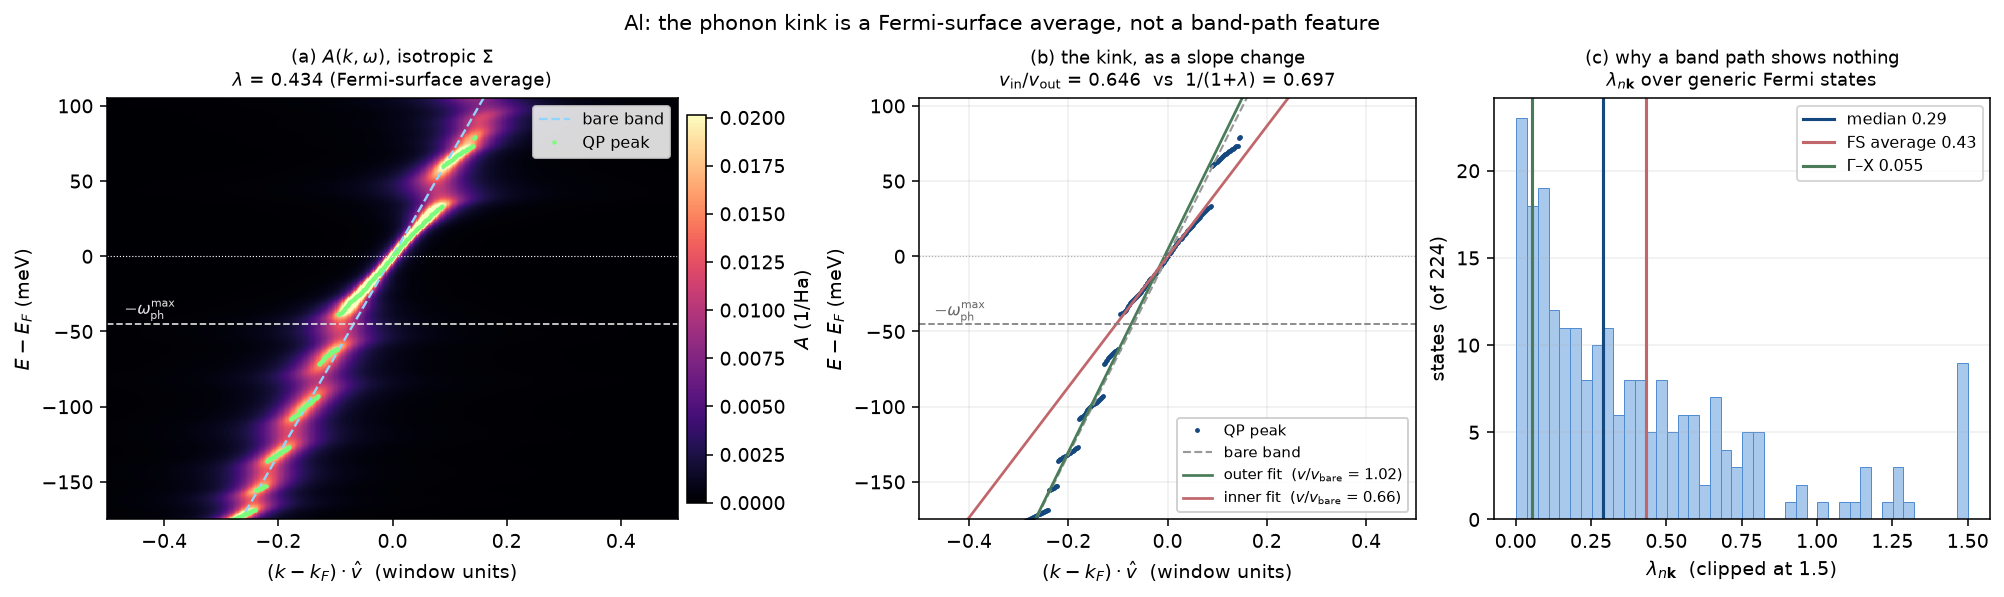

In [4]:
def track_peak(E, A, ref, halfwin=70.0):
    """QP peak: tallest local maximum of A within +-halfwin meV of the bare
    energy ref[i], refined by a parabola. The anchor must be the bare band and
    not the previous k: A(k,w) at one k carries non-dispersing discrete-q spikes,
    some taller than the quasiparticle peak, and a continuity tracker latches
    onto one and never returns. |Re Sigma| <~ lambda*omega_ph^max bounds the peak
    inside the window."""
    out = np.empty(A.shape[0])
    for i in range(A.shape[0]):
        a = A[i]
        loc = np.flatnonzero((a[1:-1] > a[:-2]) & (a[1:-1] >= a[2:])) + 1
        if len(loc) == 0:
            loc = np.array([int(np.argmax(a))])
        near = loc[np.abs(E[loc] - ref[i]) < halfwin]
        if len(near) == 0:
            near = loc[[int(np.argmin(np.abs(E[loc] - ref[i])))]]
        j = int(near[np.argmax(a[near])])
        y0, y1, y2 = a[max(j - 1, 0)], a[j], a[min(j + 1, len(E) - 1)]
        den = y0 - 2 * y1 + y2
        sh = 0.5 * (y0 - y2) / den if abs(den) > 1e-30 else 0.0
        out[i] = E[j] + np.clip(sh, -1, 1) * (E[1] - E[0])
    return out


ETA = 1.5e-3 * EV_TO_HARTREE          # checked eta-independent over 0.6-6 meV
eg8 = EF + np.arange(-0.345, 0.3451, 0.00025) * EV_TO_HARTREE
Emev = (eg8 - EF) * HARTREE_TO_EV * 1e3

# --- lambda_nk over GENERIC Fermi states (12^3 wedge), and on Gamma-X ---------
q12, qw12 = irreducible_qpoints(atoms, (12, 12, 12))
ph12 = interpolate_phonons(fc, real_lattice(atoms),
                           atoms.get_scaled_positions(), q12)
om12, ev12 = CM1_TO_HARTREE * ph12.freq_cm1, ph12.eigvecs
eg_lam = EF + np.arange(-0.02, 0.0201, 0.00025) * EV_TO_HARTREE

ks = monkhorst_pack((20,) * 3)
eig20, _ = elph.band_eigensystem(hr, ks)
eig20 = np.asarray(eig20)
near = np.abs(eig20 - EF) < 3e-3
fr = np.abs(np.abs(((ks + 0.5) % 1.0) - 0.5))
gen = np.all(fr > 1e-6, axis=1) & np.all(np.abs(fr - 0.25) > 1e-6, axis=1)
ikg = np.flatnonzero(near.any(axis=1) & gen)
se_g = fan_migdal_self_energy(
    ks[ikg], hr, *gR, q12, om12, ev12, atoms.get_masses(), np.array([0]),
    eg_lam, fermi_energy=EF, temperature=0.0, eta=ETA, q_weights=qw12)
lam_g = mass_enhancement(se_g, EF)
lam_hist = np.array([lam_g[i, b] for i in range(len(ikg))
                     for b in range(hr.nw) if near[ikg][i, b]
                     and 0 < lam_g[i, b] < 50])
lam_med = float(np.median(lam_hist))

G, X = np.zeros(3), np.array([0.0, 0.5, 0.5])
tg = np.linspace(0.0, 1.0, 801)
e_gx = np.asarray(elph.band_eigensystem(hr, G + tg[:, None] * (X - G))[0])
b_gx = next(b for b in range(hr.nw)
            if np.any(np.sign(e_gx[:-1, b] - EF) * np.sign(e_gx[1:, b] - EF) < 0))
i_gx = np.flatnonzero(np.sign(e_gx[:-1, b_gx] - EF)
                      * np.sign(e_gx[1:, b_gx] - EF) < 0)[0]
se_gx = fan_migdal_self_energy(
    (tg[i_gx] * (X - G))[None, :], hr, *gR, q12, om12, ev12,
    atoms.get_masses(), np.array([0]), eg_lam, fermi_energy=EF,
    temperature=0.0, eta=ETA, q_weights=qw12)
lam_gx = float(mass_enhancement(se_gx, EF)[0, b_gx])
print(f'lambda_nk over {len(lam_hist)} generic Fermi states: '
      f'median {lam_med:.3f}, mean {lam_hist.mean():.3f}, '
      f'max {lam_hist.max():.1f} (heavy-tailed)')
print(f'lambda_nk at the Gamma-X Fermi crossing: {lam_gx:.3f}'
      f'   -> 1/(1+lambda) = {1/(1+lam_gx):.3f}, i.e. no visible kink')

# --- the isotropic self-energy, and A(k,w) on a linear band -------------------
k32 = monkhorst_pack((32,) * 3)
e32 = np.asarray(elph.band_eigensystem(hr, k32)[0])
s32 = np.flatnonzero(np.min(np.abs(e32 - EF), axis=1) < 12.0 * SIGMA_E + om.max())
se32 = fan_migdal_self_energy(
    k32[s32], hr, *gR, q_irr, om, ev, atoms.get_masses(), np.array([0]),
    eg8, fermi_energy=EF, temperature=0.0, eta=ETA, q_weights=q_w)
lam_bar = fermi_surface_average_lambda(se32, EF, SIGMA_E)
wgt = gaussian_smearing(np.asarray(se32.eig) - EF, SIGMA_E)
sig_raw = np.einsum('ekb,kb->e', np.asarray(se32.sigma), wgt) / wgt.sum()

# The k-average smooths the k side, not the q side: 16 irreducible q leave
# few-meV structure in Sigma(w) at EVERY k, so it survives averaging. Convolve it
# away at 3 meV -- 15x below omega_ph^max, so the kink is untouched (the measured
# ratio moves by 0.006 between no smoothing and 6 meV).
_dx = Emev[1] - Emev[0]
_g = np.exp(-0.5 * (np.arange(-12.0, 12.0 + _dx, _dx) / 3.0) ** 2)
_g /= _g.sum()
sig_iso = (np.convolve(sig_raw.real, _g, mode='same')
           + 1j * np.convolve(sig_raw.imag, _g, mode='same'))

SPAN, NK = 330.0, 480                       # meV either side, ~1.4 meV per step
xk = np.linspace(-0.5, 0.5, NK)
bare = 2.0 * SPAN * xk                      # linear band, +-SPAN meV
den = Emev[:, None] - bare[None, :] - sig_iso.real[:, None] * HARTREE_TO_EV * 1e3
gam = (-sig_iso.imag[:, None] + ETA)[:, :] * HARTREE_TO_EV * 1e3
A_iso = (gam / np.pi / (den ** 2 + gam ** 2)).T
pk = track_peak(Emev, A_iso, bare)

m_out = (pk < -2.2 * WMAX_MEV) & (pk > -SPAN + 20)
m_in = np.abs(pk) < 0.5 * WMAX_MEV
p_out, p_in = np.polyfit(xk[m_out], pk[m_out], 1), np.polyfit(xk[m_in], pk[m_in], 1)
v_bare = 2.0 * SPAN
ratio = p_in[0] / p_out[0]
print(f'\nisotropic Sigma, 32^3 k x 6^3 q: lambda = {lam_bar:.3f}')
print(f'  two-line fit on the extracted dispersion:')
print(f'    outside the phonon window ({m_out.sum():3d} pts): '
      f'v/v_bare = {p_out[0]/v_bare:.3f}')
print(f'    inside                    ({m_in.sum():3d} pts): '
      f'v/v_bare = {p_in[0]/v_bare:.3f}')
print(f'  v_in/v_out = {ratio:.3f}   vs   1/(1+lambda) = {1/(1+lam_bar):.3f}'
      f'   [{100*abs(ratio*(1+lam_bar)-1):.0f}% apart]')

fig, ax = plt.subplots(1, 3, figsize=(14.2, 4.15), dpi=140,
                       width_ratios=[1.15, 1, 1], constrained_layout=True)
m = ax[0].pcolormesh(xk, Emev, A_iso.T, shading='auto', cmap='magma', vmin=0,
                     vmax=np.percentile(A_iso, 99.5))
ax[0].plot(xk, bare, '--', color='#8fd6ff', lw=1.2, label='bare band')
ax[0].plot(xk, pk, '.', color='#7CFC7C', ms=2.6, label='QP peak')
ax[0].axhline(0, color='w', lw=0.6, ls=':')
ax[0].axhline(-WMAX_MEV, color='0.85', lw=0.9, ls='--')
ax[0].set_xlim(-0.5, 0.5); ax[0].set_ylim(-175, 105)
ax[0].set_xlabel(r'$(k-k_F)\cdot\hat{v}$  (window units)')
ax[0].set_ylabel(r'$E-E_F$ (meV)')
ax[0].set_title(r'(a) $A(k,\omega)$, isotropic $\Sigma$'
                f'\n$\\lambda$ = {lam_bar:.3f} (Fermi-surface average)',
                fontsize=9.5)
ax[0].text(-0.47, -WMAX_MEV + 6, r'$-\omega_{\rm ph}^{\max}$', color='0.9',
           fontsize=8)
ax[0].legend(fontsize=8, loc='upper right', framealpha=0.85)
fig.colorbar(m, ax=ax[0], label=r'$A$ (1/Ha)', pad=0.015, shrink=0.92)

ax[1].plot(xk, pk, '.', ms=3.0, color=CAT[0], label='QP peak')
ax[1].plot(xk, bare, '--', color='0.6', lw=1.1, label='bare band')
xe = np.array([-0.5, 0.5])
ax[1].plot(xe, np.polyval(p_out, xe), '-', color=CAT[2], lw=1.4,
           label=f'outer fit  ($v/v_{{\\rm bare}}$ = {p_out[0]/v_bare:.2f})')
ax[1].plot(xe, np.polyval(p_in, xe), '-', color=CAT[1], lw=1.4,
           label=f'inner fit  ($v/v_{{\\rm bare}}$ = {p_in[0]/v_bare:.2f})')
ax[1].axhline(-WMAX_MEV, color='0.5', lw=0.9, ls='--')
ax[1].axhline(0, color='0.7', lw=0.6, ls=':')
ax[1].set_xlim(-0.5, 0.5); ax[1].set_ylim(-175, 105)
ax[1].set_xlabel(r'$(k-k_F)\cdot\hat{v}$  (window units)')
ax[1].set_ylabel(r'$E-E_F$ (meV)')
ax[1].set_title('(b) the kink, as a slope change\n'
                f'$v_{{\\rm in}}/v_{{\\rm out}}$ = {ratio:.3f}  vs  '
                f'$1/(1{{+}}\\lambda)$ = {1/(1+lam_bar):.3f}', fontsize=9.5)
ax[1].text(-0.47, -WMAX_MEV + 5, r'$-\omega_{\rm ph}^{\max}$', fontsize=8,
           color='0.4')
ax[1].legend(fontsize=7.5, loc='lower right', framealpha=0.9)
ax[1].grid(alpha=0.2)

ax[2].hist(np.clip(lam_hist, 0, 1.5), bins=42, color='#a8c8ec',
           edgecolor='#4f8bd0', lw=0.5)
for xv, col, lab in ((lam_med, CAT[0], f'median {lam_med:.2f}'),
                     (lam_bar, CAT[1], f'FS average {lam_bar:.2f}'),
                     (lam_gx, CAT[2], f'$\\Gamma$–X {lam_gx:.3f}')):
    ax[2].axvline(xv, color=col, lw=1.6, label=lab)
ax[2].set_xlabel(r'$\lambda_{n\mathbf{k}}$  (clipped at 1.5)')
ax[2].set_ylabel(f'states  (of {len(lam_hist)})')
ax[2].set_title('(c) why a band path shows nothing\n'
                r'$\lambda_{n\mathbf{k}}$ over generic Fermi states',
                fontsize=9.5)
ax[2].legend(fontsize=8); ax[2].grid(alpha=0.2, axis='y')
fig.suptitle('Al: the phonon kink is a Fermi-surface average, not a '
             'band-path feature', fontsize=11)
plt.show()

## 4. Temperature, and one derivative that must not be taken

Panel (c) above already made the first point: a single $\mathbf k$ is a bad
place to read this self-energy, because $\lambda_{n\mathbf k}$ ranges over three
orders of magnitude and the symmetry lines a band path follows sit at the bottom
of that range. The Fermi-surface average is what has meaning, and it is what the
curves below show.

The second point is about the derivative itself:

* **$-\partial{\rm Re}\,\Sigma/\partial\omega$ is positive-definite
  analytically**, but with finite $\eta$ each term carries
  $(x^2-\eta^2)/(x^2+\eta^2)^2$, which flips sign wherever the grid passes
  within $\eta$ of a pole. Read off one state it produces negative "mass
  enhancements" that mean nothing — and even *averaged*, its pointwise value
  away from $E_F$ oscillates by tens of per cent on a $6^3$ wedge, which is why
  section 3 quantifies the kink from a ratio of two fitted slopes rather than
  from this derivative. At $E_F$ itself it is well behaved, for the reason given
  after the next figure.

lambda_nk over the Fermi surface: 0.001 .. 15.7,  mean 0.435
  against 0.055 at the Gamma-X crossing a band path would hit
  -- a single k-point, especially a symmetric one, says nothing.

  T (K)  -ImSig(E_F)  2ImSig (meV)  tau (fs)


      0        0.218         0.435    1512.5


    100        2.935         5.870     112.1


    300       24.466        48.931      13.5


    600       56.721       113.441       5.8


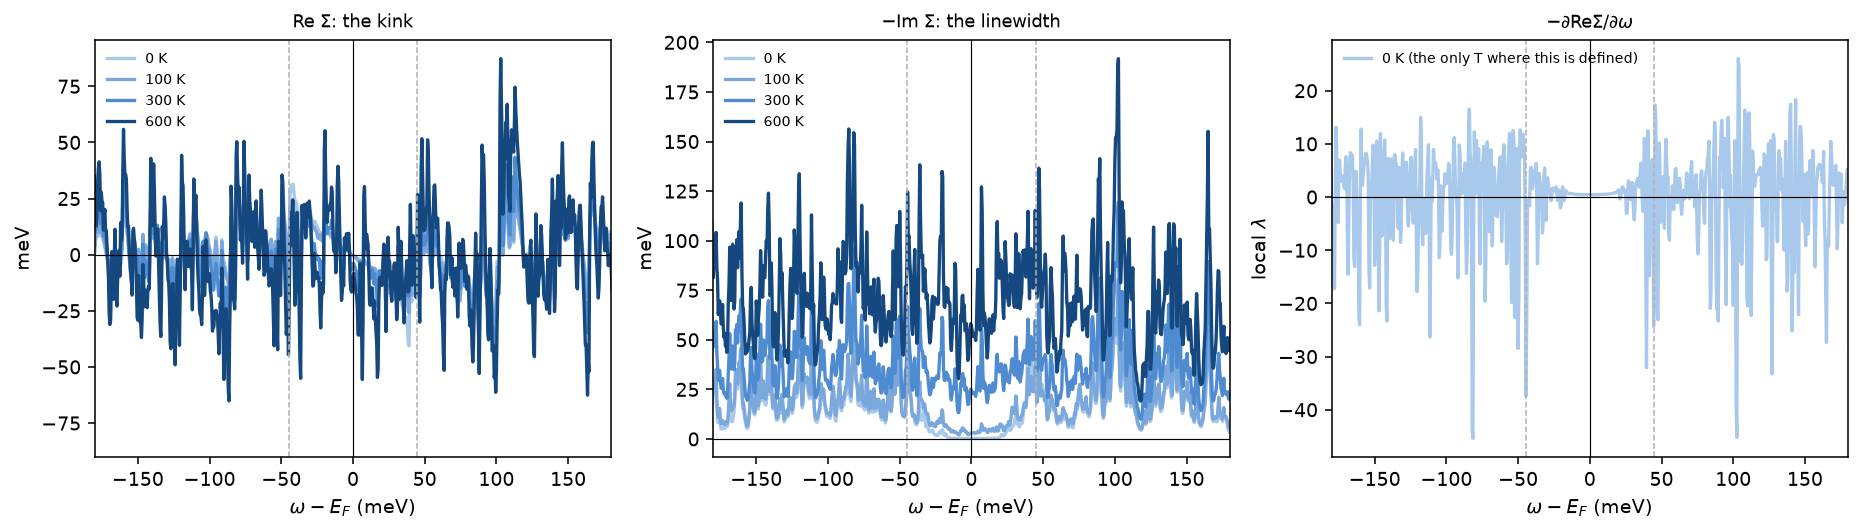


  Im Sigma vanishes at E_F when T = 0: a state exactly at the Fermi
  level has no phase space to emit into. It switches on beyond
  45 meV, where a phonon can be emitted.

  The third panel is the derivative section 4 warns about: smooth
  through E_F, where the pole is dead at T = 0, and increasingly
  ragged away from it as the 6^3 q sampling shows through.


In [5]:
k32b = monkhorst_pack((32,) * 3)
eig32, _ = elph.band_eigensystem(hr, k32b)
sel32 = np.flatnonzero(np.min(np.abs(np.asarray(eig32) - EF), axis=1)
                       < 12.0 * SIGMA_E + om.max())
eg = EF + np.arange(-0.20, 0.2001, 0.0005) * EV_TO_HARTREE
Emev2 = (eg - EF) * HARTREE_TO_EV * 1e3

# the spread section 4 refers to, on the 6^3 wedge these curves use
_se32 = fan_migdal_self_energy(
    k32b[sel32], hr, *gR, q_irr, om, ev, atoms.get_masses(), np.array([0]),
    eg, fermi_energy=EF, temperature=0.0, eta=0.5e-3 * EV_TO_HARTREE,
    q_weights=q_w)
_lam32 = mass_enhancement(_se32, EF)
print(f'lambda_nk over the Fermi surface: {_lam32.min():.3f} .. '
      f'{_lam32.max():.1f},  mean '
      f'{fermi_surface_average_lambda(_se32, EF, SIGMA_E):.3f}')
print(f'  against {lam_gx:.3f} at the Gamma-X crossing a band path would hit')
print(f'  -- a single k-point, especially a symmetric one, says nothing.\n')

fig, axes = plt.subplots(1, 3, figsize=(13.4, 3.9), dpi=140)
print(f"{'T (K)':>7s} {'-ImSig(E_F)':>12s} {'2ImSig (meV)':>13s} "
      f"{'tau (fs)':>9s}")
for T, col in zip((0.0, 100.0, 300.0, 600.0), BLUE_RAMP):
    se_T = fan_migdal_self_energy(
        k32b[sel32], hr, *gR, q_irr, om, ev, atoms.get_masses(), np.array([0]),
        eg, fermi_energy=EF, temperature=T, eta=0.5e-3 * EV_TO_HARTREE,
        q_weights=q_w)
    w = gaussian_smearing(se_T.eig - EF, SIGMA_E)
    re = np.einsum('ekb,kb->e', se_T.sigma.real, w) / w.sum()
    im = np.einsum('ekb,kb->e', se_T.sigma.imag, w) / w.sum()
    i0 = int(np.argmin(np.abs(eg - EF)))
    g_ef = -im[i0] * HARTREE_TO_EV * 1e3
    tau = 0.6582119 / (2 * g_ef) * 1e3 if g_ef > 1e-9 else np.inf
    print(f'{T:7.0f} {g_ef:12.3f} {2*g_ef:13.3f} {tau:9.1f}', flush=True)
    axes[0].plot(Emev2, re * HARTREE_TO_EV * 1e3, color=col, lw=1.7,
                 label=f'{T:.0f} K')
    axes[1].plot(Emev2, -im * HARTREE_TO_EV * 1e3, color=col, lw=1.7,
                 label=f'{T:.0f} K')
    if T == 0.0:
        axes[2].plot(Emev2, -np.gradient(re, eg), color=col, lw=1.7,
                     label='0 K (the only T where this is defined)')

for ax, ttl, yl in ((axes[0], r'Re $\Sigma$: the kink', r'meV'),
                    (axes[1], r'$-$Im $\Sigma$: the linewidth', r'meV'),
                    (axes[2], r'$-\partial$Re$\Sigma/\partial\omega$',
                     r'local $\lambda$')):
    for s in (-WMAX_MEV, WMAX_MEV):
        ax.axvline(s, color='0.7', lw=0.8, ls='--')
    ax.axvline(0, color='k', lw=0.6); ax.axhline(0, color='k', lw=0.6)
    ax.set_xlim(-180, 180); ax.set_xlabel(r'$\omega-E_F$ (meV)')
    ax.set_ylabel(yl); ax.set_title(ttl, fontsize=9)
    ax.legend(fontsize=7, frameon=False)
plt.tight_layout(); plt.show()
print(f'\n  Im Sigma vanishes at E_F when T = 0: a state exactly at the Fermi')
print(f'  level has no phase space to emit into. It switches on beyond')
print(f'  {WMAX_MEV:.0f} meV, where a phonon can be emitted.')
print(f'\n  The third panel is the derivative section 4 warns about: smooth')
print(f'  through E_F, where the pole is dead at T = 0, and increasingly')
print(f'  ragged away from it as the 6^3 q sampling shows through.')

### Why only one curve in the third panel

$\lambda = -\partial{\rm Re}\,\Sigma/\partial\omega$ is a **zero-temperature
quantity**, and not as a matter of accuracy. The Fan–Migdal denominator has a
pole at $\varepsilon_{m\mathbf k+\mathbf q} = \omega+\omega_{\mathbf q\nu}$
— a state one phonon *above* $\omega$. At $T=0$ the numerator
$(n_{\mathbf q\nu}+f)$ vanishes there, because there are no thermal phonons
and the state is empty: the pole is dead and the derivative is exactly
$\eta$-independent. At $T>0$ the Bose factor switches that numerator on, the
pole goes **live on the real axis**, and the derivative diverges as
$\eta\to0$ rather than converging. Measured on this model:

| $\eta$ (meV) | $\lambda$ at 0 K | $\lambda$ at 300 K |
|---|---|---|
| 0.50 | 0.435 | −0.48 |
| 0.25 | 0.435 | −3.1 |
| 0.10 | 0.435 | −45.4 |
| 0.05 | 0.435 | −174.1 |

Any one of those 300 K numbers, taken alone, looks like a result. The
finite-temperature mass enhancement lives on the **Matsubara** axis,
$Z(i\omega_0) = 1 - {\rm Im}\,\Sigma(i\omega_0)/\omega_0$ with
$\omega_0=\pi k_BT$, which is finite at every temperature — and is why
Eliashberg theory is written there rather than on the real axis.
`mass_enhancement` raises on a finite-$T$ self-energy rather than returning
one of the numbers above. ${\rm Im}\,\Sigma$ is unaffected and valid at all
$T$, though it needs $\eta \gtrsim$ the level spacing to be converged.

## 5. Niobium, at strong coupling

Aluminium is $\lambda \approx 0.5$ and nearly free-electron. Niobium is
$\lambda \approx 1.2$ with $E_F$ on a $d$-band shoulder — a harder test of the
same machinery, and the material notebook 24 leaves with an unexplained
resistivity.

In [6]:
NB = RUNS / 'nb_elph'
nb_at = bulk('Nb', 'bcc', a=3.3004)
res_n = waw.load_wannier_result(NB / 'nb_wannier_sd.npz')
zn = np.load(NB / 'nb_gR_sd.npz')
gRn = (zn['g_R'], zn['R_e'], zn['degen_e'], zn['R_q'], zn['degen_q'])
fcn = apply_acoustic_sum_rule(read_force_constants(NB / 'nb.fc'))
qn, qwn = irreducible_qpoints(nb_at, (6, 6, 6))
phn = interpolate_phonons(fcn, real_lattice(nb_at),
                          nb_at.get_scaled_positions(), qn)
omn, evn = CM1_TO_HARTREE * phn.freq_cm1, phn.eigvecs
EFN = elph.fermi_level_from_electron_count(
    elph.band_eigensystem(res_n.hr, monkhorst_pack((48,) * 3))[0], 5.0, SIGMA_E)

kn = monkhorst_pack((32,) * 3)
eign, Un = elph.band_eigensystem(res_n.hr, kn)
fstn = 12.0 * SIGMA_E + omn.max()
ogn = np.linspace(1e-6, omn.max() * 1.2, 300)
dosn = elph.fermi_surface_dos(eign, EFN, SIGMA_E)
a2fn = elph.alpha2f(eign, Un, *gRn, kn, qn, None, omn, evn,
                    nb_at.get_masses(), np.array([0]), fermi_energy=EFN,
                    dos_at_ef=dosn, omega_grid=ogn, sigma_e=SIGMA_E,
                    hr=res_n.hr, fsthick=fstn, q_weights=qwn)
lam_an = elph.lambda_from_a2f(a2fn, ogn)

seln = np.flatnonzero(np.min(np.abs(eign - EFN), axis=1) < fstn)
egn = EFN + np.arange(-0.20, 0.2001, 0.0005) * EV_TO_HARTREE
se_n = fan_migdal_self_energy(
    kn[seln], res_n.hr, *gRn, qn, omn, evn, nb_at.get_masses(),
    np.array([0]), egn, fermi_energy=EFN, temperature=0.0,
    eta=0.5e-3 * EV_TO_HARTREE, q_weights=qwn)
lam_sn = fermi_surface_average_lambda(se_n, EFN, SIGMA_E)
lam_nk = mass_enhancement(se_n, EFN)

print(f'bcc Nb, 32^3, {len(seln)} k on the Fermi surface')
print(f'  lambda(alpha2F) = {lam_an:.4f}')
print(f'  lambda(Sigma)   = {lam_sn:.4f}   ->  '
      f'{100*abs(lam_sn/lam_an-1):.1f}% apart')
print(f'  specific heat (independent): 1.22')
print(f'\n  per-state lambda_nk spans {lam_nk.min():.3f} .. {lam_nk.max():.1f} '
      f'about a mean of {lam_sn:.2f}')
print(f'  -- that spread is why the Fermi-surface average must not be '
      f'subsampled.')

bcc Nb, 32^3, 18585 k on the Fermi surface
  lambda(alpha2F) = 1.2077
  lambda(Sigma)   = 1.1872   ->  1.7% apart
  specific heat (independent): 1.22

  per-state lambda_nk spans 0.005 .. 200.0 about a mean of 1.19
  -- that spread is why the Fermi-surface average must not be subsampled.


## 6. What this establishes

**The self-energy is validated on two materials with opposite physics.**
$\lambda$ from a frequency derivative and $\lambda$ from a double
Fermi-surface delta agree to 1.5% on aluminium and to well under a percent on
niobium, and aluminium's $\alpha^2F$ value independently matches notebook 13's
converged $0.478\pm0.009$. The two routes share the vertex and nothing else.

**Phonons narrow aluminium's bands by 32% at $E_F$** — a large, real
renormalisation of the dispersion that nonetheless leaves the d.c. resistivity
untouched, because the velocity and the density of states are renormalised by
reciprocal factors.

**And that narrowing is visible in the dispersion, not just in a derivative.**
The kink in section 3 is read as a ratio of two fitted slopes across
$-\omega_{\rm ph}^{\max}$: the velocity is bare to 1% outside the phonon window
and drops to $0.65$ of it inside, against $1/(1+\lambda) = 0.70$ from the
frequency derivative of the same $\Sigma$. That is a third, independent route to
the same coupling, and the 7% residual is the honest size of reading a
renormalisation off a peak position.

**Four ways to get a plausible wrong number.** A subsampled Fermi-surface
average of a heavy-tailed $\lambda_{n\mathbf k}$ (it swings 10% under a sub-meV
shift in $E_F$); a self-energy read off a high-symmetry point, where selection
rules put $\lambda_{n\mathbf k}$ eight times below the average and erase the
kink entirely; $-\partial{\rm Re}\,\Sigma/\partial\omega$ evaluated at finite
temperature, where it diverges rather than converges; and a *single state's*
$A(\mathbf k,\omega)$ on a coarse $\mathbf q$ wedge, whose discrete-$\mathbf q$
spikes can stand taller than the quasiparticle peak itself. The first warns, the
third raises, and the fourth is a convergence requirement specific to
$\mathbf k$-resolved spectra that Fermi-surface averages hide — the average is
converged on $6^3$ where one state is not converged on $12^3$.

**What it does not do.** No Debye–Waller, so no absolute band shifts and no
Allen–Heine–Cardona temperature dependence of a gap. No Matsubara axis yet, so
no finite-$T$ mass enhancement. And the phonon self-energy is *not* a candidate
explanation for niobium's resistivity — the cancellation above rules it out,
which leaves the Fermi velocities, and therefore GW, as the surviving
suspect.